# **NOTEBOOK 4: Decision Tree & Random Forest Models**

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, median_absolute_error
import seaborn as sns
from matplotlib import pyplot as plt

## Load Dataset

In [7]:
def load_dataset():
    file_path = Path.home() / 'Documents/IDX Internship/Raw Data'
    
    # all 30 datasets
    files = [
        file_path / 'CRMLSSold20220101_20231231_filled.csv', file_path / 'CRMLSSold202401_filled.csv',
        file_path / 'CRMLSSold202402_filled.csv', file_path / 'CRMLSSold202403_filled.csv',
        file_path / 'CRMLSSold202404_filled.csv', file_path / 'CRMLSSold202405_filled.csv',
        file_path / 'CRMLSSold202406_filled.csv', file_path / 'CRMLSSold202407_filled.csv',
        file_path / 'CRMLSSold202408.csv', file_path / 'CRMLSSold202409.csv',
        file_path / 'CRMLSSold202410.csv', file_path / 'CRMLSSold202411.csv',
        file_path / 'CRMLSSold202412.csv', file_path / 'CRMLSSold202501_filled.csv',
        file_path / 'CRMLSSold202502.csv', file_path / 'CRMLSSold202503.csv',
        file_path / 'CRMLSSold202504.csv', file_path / 'CRMLSSold202505.csv',
        file_path / 'CRMLSSold202506.csv', file_path / 'CRMLSSold202507.csv',
        file_path / 'CRMLSSold202508.csv', file_path / 'CRMLSSold202509.csv',
        file_path / 'CRMLSSold202510.csv', file_path / 'CRMLSSold202511.csv',
        file_path / 'CRMLSSold202512.csv', file_path / 'CRMLSSold202601.csv',
        file_path / 'CRMLSSold202602.csv', file_path / 'CRMLSSold202603.csv',
        file_path / 'CRMLSSold202604.csv', file_path / 'CRMLSSold202605.csv',
    ]
    
    # dtype to str to handle mixed value types for some columns
    data_dfs = [pd.read_csv(f, dtype={'WaterfrontYN': str, 'PostalCode': str, 'latfilled': str, 'lonfilled': str,
                                      'ElementarySchool': str, 'BuilderName': str, 'CoBuyerAgentFirstName': str,
                                      'PoolPrivateYN': str}) for f in files]
    df = pd.concat(data_dfs, ignore_index=True)

    return df

In [8]:
init_df = load_dataset()
init_df.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
0,"Carpet,Wood",True,NaN,NaN,True,98000.0,556366533,michellefsellsoc@gmail.com,2022-02-25,95000.0,...,0.0,ABC Unified,92708,0.0,NaN,NaN,False,False,NaN,NaN
1,NaN,False,NaN,NaN,False,1200.0,556366530,dineshcalre@gmail.com,2022-02-19,1200.0,...,1.0,Apple Valley Unified,92308,0.0,43000.0,NaN,False,False,NaN,NaN
2,NaN,True,NaN,NaN,False,1100000.0,556366044,cindydavishomes@gmail.com,2022-04-15,1100000.0,...,1.0,Solana Beach,92075,370.0,NaN,NaN,False,False,NaN,NaN
3,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,2022-01-04,2499999.0,...,2.0,Carlsbad Unified,92008,140.0,13376.0,NaN,False,False,NaN,NaN
4,"Carpet,Tile",NaN,NaN,NaN,NaN,598888.0,556365290,steven@westsideres.com,2022-01-12,640000.0,...,1.0,Other,95111,300.0,2738.0,NaN,False,False,NaN,NaN


<Axes: xlabel='ClosePrice', ylabel='Density'>

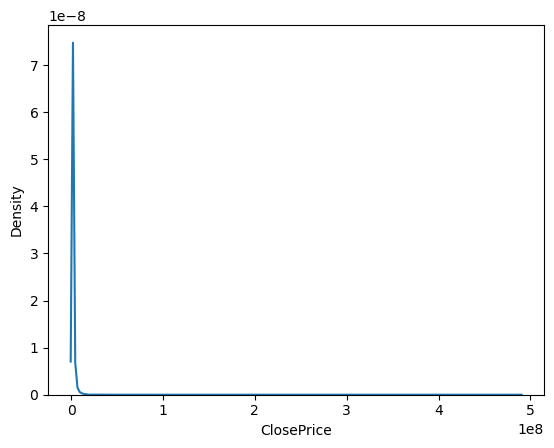

In [9]:
sns.kdeplot(data=init_df[init_df['ClosePrice'] < 500000000]['ClosePrice'])

## Data Preprocessing

In [38]:
def preprocessing(encode_loc=True):

    # load dataset
    df = load_dataset()
    
    # restrict analysis to residential and single family
    df = df[
        (df['PropertyType'] == 'Residential') &
        (df['PropertySubType'] == 'SingleFamilyResidence')].copy()

    # convert CloseDate to datetime dtype
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])


    preprocessed_df = df.copy()
    

    ####################
    ### drop columns ###
    ####################
    
    # drop columns not known at prediction time
    drop_cols = ['ListPrice', 'DaysOnMarket', 'OriginalListPrice']
    preprocessed_df = preprocessed_df.drop(columns=drop_cols)

    # count missing values
    missing = pd.DataFrame({
        'Total Missing Values': preprocessed_df.isnull().sum(),
        'Proportion Missing': preprocessed_df.isnull().mean()
    })

    # drop column if null rate above 50%
    threshold = 0.5
    null_50 = missing[missing['Proportion Missing'] > threshold].index.tolist()
    preprocessed_df = preprocessed_df.drop(columns=null_50)

    # drop columns with no plausible relationship to ClosePrice
    unrelated = ['ContractStatusChangeDate', 'MlsStatus', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'ListingId',
                 'PurchaseContractDate', 'ListingContractDate', 'ListAgentEmail', 'ListOfficeName', 'BuyerOfficeName',
                 'ListingKey', 'ListingKeyNumeric', 'ListAgentFirstName', 'ListAgentLastName', 'StreetNumberNumeric',
                 'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerOfficeAOR', 'BuyerAgentAOR', 'ListAgentAOR',
                 'UnparsedAddress']
    preprocessed_df = preprocessed_df.drop(columns=unrelated)

    # drop location variables (redundant due to Latitude and Longitude)
    preprocessed_df = preprocessed_df.drop(columns=['MLSAreaMajor', 'PostalCode'])
    

    ###################################
    ### convert unreasonable values ###
    ###################################

    # convert impossible coordinates to NaN
    invalid_coords = (
        (preprocessed_df['Latitude'] < -90) | (preprocessed_df['Latitude'] > 90) |
        (preprocessed_df['Longitude'] < -180) | (preprocessed_df['Longitude'] > 180) |
        (preprocessed_df['Latitude'] == 0) | (preprocessed_df['Longitude'] == 0)
    )
    preprocessed_df.loc[invalid_coords, ['Latitude','Longitude']] = np.nan

    # remove LivingArea values of 0
    preprocessed_df.loc[preprocessed_df['LivingArea'] <= 0, 'LivingArea'] = np.nan

    # remove ParkingTotal values less than 0 and greater than 100
    preprocessed_df.loc[preprocessed_df['ParkingTotal'] < 0, 'ParkingTotal'] = np.nan
    preprocessed_df.loc[preprocessed_df['ParkingTotal'] > 100, 'ParkingTotal'] = np.nan


    # drop rows with missing values for target variable and other important features with very little null values
    preprocessed_df = preprocessed_df.dropna(subset=['ClosePrice', 'LivingArea'])
    

    #######################
    ### fill NaN values ###
    #######################

    # fill values with less than 50% null rate
    # sentinel fill
    preprocessed_df['ParkingTotal'] = preprocessed_df['ParkingTotal'].fillna(0)
    preprocessed_df['GarageSpaces'] = preprocessed_df['GarageSpaces'].fillna(0)
    preprocessed_df['MainLevelBedrooms'] = preprocessed_df['MainLevelBedrooms'].fillna(0)
    
    # median fill
    for col in ['LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Latitude', 'Longitude', 'BedroomsTotal',
                'BathroomsTotalInteger']:
        preprocessed_df[col] = preprocessed_df[col].fillna(preprocessed_df[col].median())

    # create binary has_hoa feature from AssociationFee
    preprocessed_df['AssociationFee'] = preprocessed_df['AssociationFee'].fillna(0)
    preprocessed_df["has_hoa"] = (preprocessed_df["AssociationFee"] > 0).astype(int)

    # create binary has_garage feature from GarageSpaces
    preprocessed_df['GarageSpaces'] = preprocessed_df['GarageSpaces'].fillna(0)
    preprocessed_df['has_garage'] = (preprocessed_df['GarageSpaces'] > 0).astype(int)
    preprocessed_df = preprocessed_df.drop(columns=['GarageSpaces'])
    
    # drop features with zero variance
    preprocessed_df = preprocessed_df.drop(columns=['PropertyType', 'PropertySubType'])

    # keep only one area column (LotSizeSquareFeet)
    preprocessed_df = preprocessed_df.drop(columns=['LotSizeArea', 'LotSizeAcres'])

    # fill null values for certain bool values with False
    for col in ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']:
        preprocessed_df[col] = preprocessed_df[col].astype(bool)
        preprocessed_df[col] = preprocessed_df[col].fillna(False).astype(int)

    # fill missing values for certain categorical variables with 'Unknown'
    for col in ['Flooring', 'HighSchoolDistrict', 'Levels', 'City']:
        preprocessed_df[col] = preprocessed_df[col].fillna('Unknown')

    # replace StateOrProvince (almost no variance) with binary InCalifornia variable
    preprocessed_df["InCalifornia"] = (preprocessed_df["StateOrProvince"] == "CA").astype(int)
    preprocessed_df = preprocessed_df.drop(columns=['StateOrProvince'])
    
    # fill missing value for CountyOrParish with mode
    preprocessed_df['CountyOrParish'] = preprocessed_df['CountyOrParish'].fillna(
        preprocessed_df['CountyOrParish'].mode()[0]
    )


    ####################################
    ### encode categorical variables ###
    ####################################

    # multi-label encode Flooring feature
    preprocessed_df['Flooring_SeeRemarks'] = (preprocessed_df['Flooring'].str.contains('SeeRemarks').astype(int))
    preprocessed_df['Flooring'] = (preprocessed_df['Flooring'].str.replace('SeeRemarks,?', '', regex=True))
    flooring_dummies = (preprocessed_df['Flooring'].str.get_dummies(sep=','))
    
    preprocessed_df = pd.concat(
        [preprocessed_df.drop(columns=['Flooring']), flooring_dummies.add_prefix('Flooring_')], axis=1)

    # multi-label encode Levels
    # create multi-label dummy variables
    levels_dummies = (preprocessed_df['Levels'].str.get_dummies(sep=','))
    levels_dummies = levels_dummies.add_prefix('Levels_') # add prefix
    
    preprocessed_df = pd.concat([preprocessed_df.drop(columns=['Levels']),levels_dummies],axis=1)


    if encode_loc:
        
        # one-hot encode CountyOrParish
        preprocessed_df['CountyOrParish'] = (preprocessed_df['CountyOrParish'].str.title()) # standard capitalization
        preprocessed_df['CountyOrParish'] = (preprocessed_df['CountyOrParish'].replace(
            ['Foreign Country', 'Other County', 'Other State', 'Other'], 'Other')) # replace non-counties with 'Other'
        preprocessed_df = pd.get_dummies(preprocessed_df, columns=['CountyOrParish'], drop_first=True, dtype='int8')
    
        # group cities with less than 500 entires and one-hot encode City
        city_counts = preprocessed_df['City'].value_counts()
        rare_cities = city_counts[city_counts < 500].index
        preprocessed_df['City'] = (preprocessed_df['City'].replace(rare_cities, 'Other'))
        preprocessed_df = pd.get_dummies(preprocessed_df, columns=['City'], drop_first=True, dtype='int8')
    
        # # group districts with less than 100 entries and one-hot encode HighSchoolDistrict
        # district_counts = preprocessed_df['HighSchoolDistrict'].value_counts()
        # rare_districts = district_counts[district_counts < 100].index
        # preprocessed_df['HighSchoolDistrict'] = (preprocessed_df['HighSchoolDistrict'].replace(rare_districts, 'Other'))
        # preprocessed_df = pd.get_dummies(preprocessed_df, columns=['HighSchoolDistrict'], drop_first=True, dtype='int8')

    else:
        preprocessed_df = preprocessed_df.drop(columns=['CountyOrParish', 'City', 'HighSchoolDistrict'])
    

    return preprocessed_df


In [8]:
preprocessed_df = preprocessing()
preprocessed_df.shape

(398787, 561)

## Train-Test Split
Parameters:
* df: dataframe containing CloseDate
* train_months: number of months before test month to use for training

Returns:
* X_train, X_test, y_train, y_test

In [11]:
def train_test_split(df, train_months):

    df = df.copy()

    # ensure datetime
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])

    # get monthly periods
    df['CloseMonth'] = df['CloseDate'].dt.to_period('M')

    # most recent month becomes test
    latest_month = df['CloseMonth'].max()

    test_df = df[df['CloseMonth'] == latest_month]

    # X months immediately before test month
    train_start = latest_month - train_months

    train_df = df[(df['CloseMonth'] < latest_month) & (df['CloseMonth'] >= train_start)]

    # remove date columns
    train_df = train_df.drop(columns=['CloseDate', 'CloseMonth'])

    test_df = test_df.drop(columns=['CloseDate', 'CloseMonth'])

    # separate target
    X_train = train_df.drop(columns=['ClosePrice'])
    y_train = train_df['ClosePrice']

    X_test = test_df.drop(columns=['ClosePrice'])
    y_test = test_df['ClosePrice']

    return X_train, X_test, y_train, y_test

## Evaluation Metrics

In [12]:
# define MdAPE
def mdape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    ape = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100
    return np.median(ape)

# define metrics function
def metrics(y_true, y_pred):
      return {
          'R2': f"{r2_score(y_true, y_pred):.4f}",
          'MAE': f"${mean_absolute_error(y_true, y_pred):.2f}",
          'RMSE': f"${root_mean_squared_error(y_true, y_pred):.2f}",
          'MedianAbsoluteError': f"${median_absolute_error(y_true, y_pred):.2f}",
          'MDAPE': f"{mdape(y_true, y_pred):.2f}%"
      }

## Load Preprocessed Data and Split Train/Test

In [39]:
df = preprocessing(encode_loc=True)

X = 30
X_train, X_test, y_train, y_test = train_test_split(df, X)

In [34]:
X_train.head()

,ViewYN,PoolPrivateYN,Latitude,Longitude,LivingArea,AttachedGarageYN,ParkingTotal,YearBuilt,BathroomsTotalInteger,BedroomsTotal,...,HighSchoolDistrict_West Covina,HighSchoolDistrict_Westminster Unified,HighSchoolDistrict_Westside Union,HighSchoolDistrict_Whittier Union High,HighSchoolDistrict_William S. Hart Union,HighSchoolDistrict_Willows Unified,HighSchoolDistrict_Wiseburn Unified,HighSchoolDistrict_Yosemite Unified,HighSchoolDistrict_Yucaipa/Calimesa Unified,HighSchoolDistrict_Yucca Valley
7578,0,1,33.941807,-118.239928,1350.0,0,2.0,1974.0,2.0,4.0,...,0,0,0,0,0,0,0,0,0,0
10868,0,1,32.659210,-117.097531,1974.0,1,4.0,2023.0,4.0,4.0,...,0,0,0,0,0,0,0,0,0,0
10869,0,1,32.659251,-117.097312,1974.0,1,2.0,2023.0,4.0,4.0,...,0,0,0,0,0,0,0,0,0,0
10930,1,1,34.534363,-117.960529,2400.0,1,2.0,2007.0,3.0,4.0,...,0,0,0,0,0,0,0,0,0,0
13088,1,1,33.524038,-117.023755,5256.0,1,5.0,2022.0,7.0,6.0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
X_train.columns

Index(['ViewYN', 'PoolPrivateYN', 'Latitude', 'Longitude', 'LivingArea',
       'AttachedGarageYN', 'ParkingTotal', 'YearBuilt',
       'BathroomsTotalInteger', 'BedroomsTotal',
       ...
       'HighSchoolDistrict_West Covina',
       'HighSchoolDistrict_Westminster Unified',
       'HighSchoolDistrict_Westside Union',
       'HighSchoolDistrict_Whittier Union High',
       'HighSchoolDistrict_William S. Hart Union',
       'HighSchoolDistrict_Willows Unified',
       'HighSchoolDistrict_Wiseburn Unified',
       'HighSchoolDistrict_Yosemite Unified',
       'HighSchoolDistrict_Yucaipa/Calimesa Unified',
       'HighSchoolDistrict_Yucca Valley'],
      dtype='object', length=559)

## Filter Outliers
- Compute 0.5th and 99.5th percentiles on train dataset
- Apply these thresholds to test dataset
- Filter both train and test datasets with these thresholds

In [15]:
# compute ClosePrice thresholds from training set only
lower = y_train.quantile(0.005)
upper = y_train.quantile(0.995)

# apply thresholds to train and test
train_filter = y_train.between(lower, upper)
test_filter = y_test.between(lower, upper)

X_train = X_train[train_filter]
y_train = y_train[train_filter]
X_test = X_test[test_filter]
y_test = y_test[test_filter]

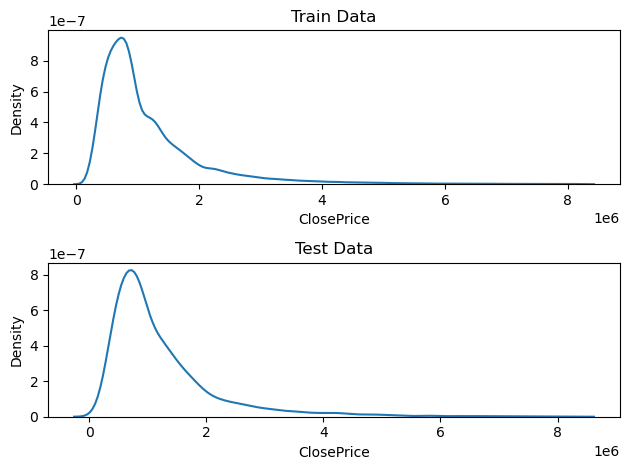

In [16]:
fig, ax = plt.subplots(2, 1)
sns.kdeplot(data=y_train, ax=ax[0])
ax[0].set_title('Train Data')
sns.kdeplot(data=y_test, ax=ax[1])
ax[1].set_title('Test Data')
plt.tight_layout()

## Decision Tree

In [16]:
# train and evaluate decision tree regressor model
dt = DecisionTreeRegressor(random_state=123)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_metrics = metrics(y_test, dt_pred)

print(dt_metrics)

{'R2': '0.7700', 'MAE': '$229750.90', 'RMSE': '$467413.64', 'MedianAbsoluteError': '$100000.00', 'MDAPE': '10.71%'}


## Random Forest

In [17]:
# train and evaluate random forest model
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=123, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_metrics = metrics(y_test, rf_pred)

print(rf_metrics)

{'R2': '0.8425', 'MAE': '$210082.44', 'RMSE': '$386840.01', 'MedianAbsoluteError': '$105350.04', 'MDAPE': '11.20%'}


## Comparison With Baseline (Linear Regression)

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_metrics = metrics(y_test, lr_pred)

print(lr_metrics)

{'R2': '0.7710', 'MAE': '$285079.05', 'RMSE': '$466404.36', 'MedianAbsoluteError': '$183143.09', 'MDAPE': '19.08%'}


## Test models with encode_loc=False

In [19]:
noloc_df = preprocessing(encode_loc=False)

X = 30
X_train_noloc, X_test_noloc, y_train_noloc, y_test_noloc = train_test_split(noloc_df, X)

In [20]:
# linear regression
lr_noloc = LinearRegression()
lr_noloc.fit(X_train_noloc, y_train_noloc)
lr_noloc_pred = lr_noloc.predict(X_test_noloc)

lr_noloc_metrics = metrics(y_test_noloc, lr_noloc_pred)

In [21]:
# decision tree
dt_noloc = DecisionTreeRegressor(random_state=123)
dt_noloc.fit(X_train_noloc, y_train_noloc)
dt_noloc_pred = dt_noloc.predict(X_test_noloc)

dt_noloc_metrics = metrics(y_test_noloc, dt_noloc_pred)

In [22]:
# random forest
rf_noloc = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=123, n_jobs=-1)
rf_noloc.fit(X_train_noloc, y_train_noloc)
rf_noloc_pred = rf_noloc.predict(X_test_noloc)

rf_noloc_metrics = metrics(y_test_noloc, rf_noloc_pred)

In [23]:
results = pd.DataFrame(
    [lr_metrics, dt_metrics, rf_metrics, lr_noloc_metrics, dt_noloc_metrics, rf_noloc_metrics],
    index = ['Linear Regression',
             'Decision Tree',
             'Random Forest',
             'Linear Regression (No Location Encoding)',
             'Decision Tree (No Location Encoding)',
             'Random Forest (No Location Encoding)']
)

results

,R2,MAE,RMSE,MedianAbsoluteError,MDAPE
Linear Regression,0.7710,$285079.05,$466404.36,$183143.09,19.08%
Decision Tree,0.7700,$229750.90,$467413.64,$100000.00,10.71%
Random Forest,0.8425,$210082.44,$386840.01,$105350.04,11.20%
Linear Regression (No Location Encoding),0.3386,$515402.76,$1363385.76,$323764.86,32.02%
Decision Tree (No Location Encoding),0.2873,$292465.07,$1415304.35,$100000.00,11.11%
Random Forest (No Location Encoding),0.0135,$290433.48,$1665099.19,$111592.96,11.77%


## Feature Importance

In [40]:
# decision tree feature importance
dt_importances = pd.DataFrame({'Feature': X_train.columns,
                               'Importance': dt.feature_importances_}
                               ).sort_values(by='Importance', ascending=False)
print(dt_importances)

# random forest feature importance
rf_importances = pd.DataFrame({'Feature': X_train.columns,
                               'Importance': rf.feature_importances_}
                             ).sort_values(by='Importance', ascending=False)
print(rf_importances)

                       Feature  Importance
8        BathroomsTotalInteger    0.255083
4                   LivingArea    0.162116
3                    Longitude    0.125429
2                     Latitude    0.119033
78  CountyOrParish_Santa Clara    0.044117
..                         ...         ...
46     CountyOrParish_Humboldt    0.000000
35       CountyOrParish_Alpine    0.000000
42    CountyOrParish_Del Norte    0.000000
1                PoolPrivateYN    0.000000
81       CountyOrParish_Sierra    0.000000

[559 rows x 2 columns]
                                Feature  Importance
8                 BathroomsTotalInteger    0.282303
4                            LivingArea    0.173988
3                             Longitude    0.124192
2                              Latitude    0.113604
78           CountyOrParish_Santa Clara    0.049608
..                                  ...         ...
439   HighSchoolDistrict_Madera Unified    0.000000
221                        City_Norwalk    0

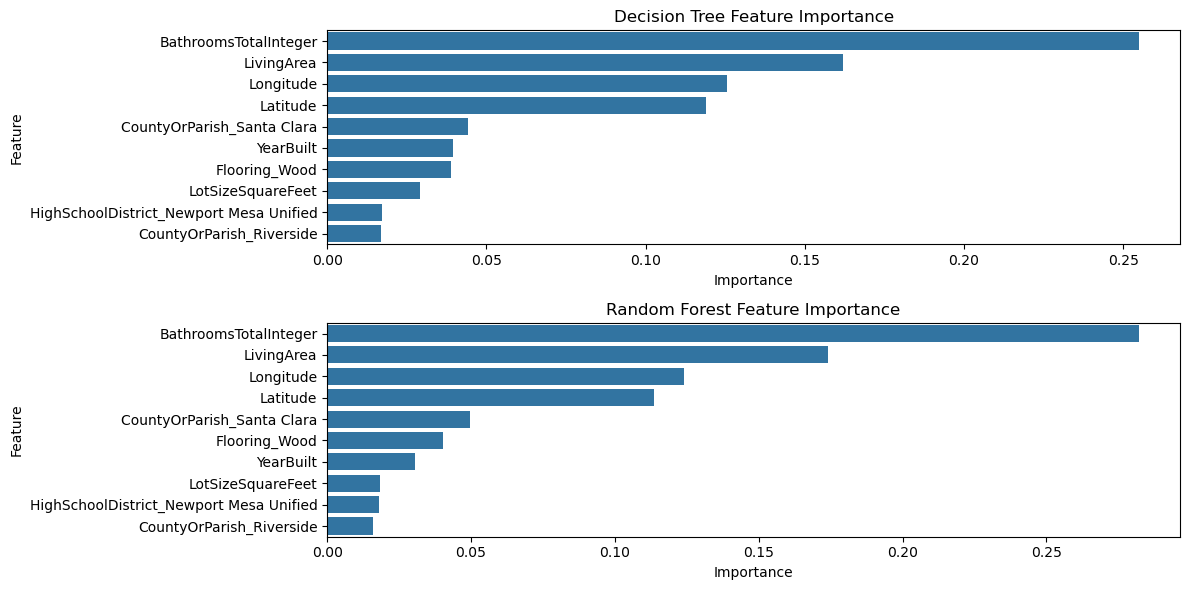

In [47]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
sns.barplot(data=dt_importances.head(10), x='Importance', y='Feature', ax=ax[0])
ax[0].set_title('Decision Tree Feature Importance')
sns.barplot(data=rf_importances.head(10), x='Importance', y='Feature', ax=ax[1])
ax[1].set_title('Random Forest Feature Importance')
plt.tight_layout()

## Save Cleaned Data

In [40]:
df.to_csv("preprocessed_data.csv", index=False)

In [41]:
preprocessed_df = pd.read_csv('preprocessed_data.csv')
preprocessed_df.head()

,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,AttachedGarageYN,ParkingTotal,YearBuilt,...,City_Westlake Village,City_Westminster,City_Whittier,City_Wildomar,City_Winchester,City_Winnetka,City_Woodland Hills,City_Yorba Linda,City_Yucaipa,City_Yucca Valley
0,1,1,2022-01-04,2499999.0,33.147270,-117.340604,2645.0,1,2.0,2016.0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,2022-01-10,640000.0,34.235979,-117.202269,2070.0,1,1.0,2007.0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,2022-03-23,438000.0,34.114130,-117.442493,1174.0,1,2.0,1960.0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,2022-01-10,615000.0,33.783767,-116.447280,1996.0,0,4.0,2005.0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,2022-01-19,399990.0,39.767729,-121.586400,1422.0,1,2.0,2021.0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
# dropped HighSchoolDistrict columns
preprocessed_df.columns

Index(['ViewYN', 'PoolPrivateYN', 'CloseDate', 'ClosePrice', 'Latitude',
       'Longitude', 'LivingArea', 'AttachedGarageYN', 'ParkingTotal',
       'YearBuilt',
       ...
       'City_Westlake Village', 'City_Westminster', 'City_Whittier',
       'City_Wildomar', 'City_Winchester', 'City_Winnetka',
       'City_Woodland Hills', 'City_Yorba Linda', 'City_Yucaipa',
       'City_Yucca Valley'],
      dtype='object', length=326)

# **Additional Feature Engineering**

## Install geopandas

In [4]:
# install geopandas
#%pip install geopandas

In [5]:
import geopandas as gpd

## California School District
- Filter the school district dataset to only include DistrictType = "Unified"
- Convert each property’s Latitude and Longitude into a geographic point
- Perform a spatial join (gpd.sjoin) to determine which Unified School District polygon contains each property
- Add the resulting DistrictName as a new column in dataset

In [55]:
# read GeoJSON
districts = gpd.read_file(
    Path.home() / 'Documents/IDX Internship/Resources/CaliforniaSchoolDistricts.geojson'
)

districts.head()

,OBJECTID,Year,FedID,CDCode,CDSCode,CountyName,DistrictName,DistrictType,GradeLow,GradeHigh,...,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,LocaleCode,LocaleDesc,geometry
0,1,2025-26,0601770,0161119,01611190000000,Alameda,Alameda Unified,Unified,PK,12,...,0,0.0,1302,12.1,4259,39.5,11.248886,21,"21 - Suburban, Large","MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,2,2025-26,0601860,0161127,01611270000000,Alameda,Albany City Unified,Unified,PK,12,...,0,0.0,363,9.7,1247,33.3,1.789975,21,"21 - Suburban, Large","POLYGON ((-13612893.866 4565099.707, -13612896..."
2,3,2025-26,0604740,0161143,01611430000000,Alameda,Berkeley Unified,Unified,PK,12,...,0,0.0,1118,11.9,2710,28.8,10.434281,12,"12 - City, Midsize","POLYGON ((-13609482.48 4565074.597, -13609483...."
3,4,2025-26,0607800,0161150,01611500000000,Alameda,Castro Valley Unified,Unified,PK,12,...,2,0.0,1186,12.2,3784,39.0,66.885261,21,"21 - Suburban, Large","MULTIPOLYGON (((-13582508.535 4529067.071, -13..."
4,5,2025-26,0612630,0161168,01611680000000,Alameda,Emery Unified,Unified,PK,12,...,0,0.0,98,16.1,407,66.7,1.273923,21,"21 - Suburban, Large","POLYGON ((-13613999.038 4555592.769, -13614126..."


In [56]:
# filter unified districts
districts = districts[districts['DistrictType'] == 'Unified'].copy()

In [51]:
districts['DistrictType'].value_counts

<bound method IndexOpsMixin.value_counts of 0      Unified
1      Unified
2      Unified
3      Unified
4      Unified
        ...   
926    Unified
927    Unified
928    Unified
930    Unified
934    Unified
Name: DistrictType, Length: 345, dtype: object>

In [46]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

In [57]:
# convert properties to geographic point
properties = gpd.GeoDataFrame(
    preprocessed_df,
    geometry=gpd.points_from_xy(preprocessed_df['Longitude'], preprocessed_df['Latitude']),
    crs='EPSG:4326'
)

districts = districts.to_crs(properties.crs)

print(properties.crs)
print(districts.crs)

EPSG:4326
EPSG:4326


In [58]:
# perform spatial join
properties = gpd.sjoin(properties,
                       districts,
                       how='left',
                       predicate='within')

In [68]:
preprocessed_df['UnifiedSchoolDistrict'] = properties['DistrictName']
preprocessed_df['UnifiedSchoolDistrict'].value_counts()

UnifiedSchoolDistrict
Los Angeles Unified            38275
San Diego Unified              10571
Capistrano Unified              7090
Desert Sands Unified            7030
Palm Springs Unified            5983
                               ...  
Alpine County Unified              2
Death Valley Unified               1
Big Sur Unified                    1
Sierra-Plumas Joint Unified        1
Mountain Valley Unified            1
Name: count, Length: 330, dtype: int64

In [93]:
# one-hot encode new school districts feature
updated_df = pd.get_dummies(preprocessed_df,
                            columns=['UnifiedSchoolDistrict'],
                            drop_first=True,
                            dtype='int8',
                            prefix='',
                            prefix_sep='')

# drop old HighSchoolDistrict column
updated_df = updated_df.drop(columns=['HighSchoolDistrict'])

In [108]:
updated_df.columns

Index(['ViewYN', 'PoolPrivateYN', 'CloseDate', 'ClosePrice', 'Latitude',
       'Longitude', 'LivingArea', 'AttachedGarageYN', 'ParkingTotal',
       'YearBuilt',
       ...
       'Willits Unified', 'Willows Unified', 'Windsor Unified',
       'Winters Joint Unified', 'Wiseburn Unified', 'Woodlake Unified',
       'Woodland Joint Unified', 'Yosemite Unified', 'Yuba City Unified',
       'Yucaipa-Calimesa Joint Unified'],
      dtype='object', length=654)

## Property Age

In [112]:
# subtract year built from close date
updated_df['CloseDate'] = pd.to_datetime(updated_df['CloseDate'])
updated_df['PropertyAge'] = (updated_df['CloseDate'].dt.year - updated_df['YearBuilt'])

updated_df = updated_df.drop(columns=['YearBuilt'])

## Bed/Bath Ratio

In [114]:
# divide bedrooms by bathrooms
updated_df['BedBathRatio'] = (updated_df['BedroomsTotal'] / updated_df['BathroomsTotalInteger'])

# replace division by zero values with 0
updated_df['BedBathRatio'] = (updated_df['BedBathRatio'].replace([np.inf, -np.inf], np.nan).fillna(0))

In [115]:
updated_df.columns

Index(['ViewYN', 'PoolPrivateYN', 'CloseDate', 'ClosePrice', 'Latitude',
       'Longitude', 'LivingArea', 'AttachedGarageYN', 'ParkingTotal',
       'BathroomsTotalInteger',
       ...
       'Windsor Unified', 'Winters Joint Unified', 'Wiseburn Unified',
       'Woodlake Unified', 'Woodland Joint Unified', 'Yosemite Unified',
       'Yuba City Unified', 'Yucaipa-Calimesa Joint Unified', 'PropertyAge',
       'BedBathRatio'],
      dtype='object', length=655)

## Retain Models

In [116]:
# split train-test datasets
X = 30
X_train, X_test, y_train, y_test = train_test_split(updated_df, X)

In [117]:
X_train.head()

,ViewYN,PoolPrivateYN,Latitude,Longitude,LivingArea,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,...,Windsor Unified,Winters Joint Unified,Wiseburn Unified,Woodlake Unified,Woodland Joint Unified,Yosemite Unified,Yuba City Unified,Yucaipa-Calimesa Joint Unified,PropertyAge,BedBathRatio
3749,0,1,33.941807,-118.239928,1350.0,0,2.0,2.0,4.0,0,...,0,0,0,0,0,0,0,0,49.0,2.000000
4958,0,1,32.659210,-117.097531,1974.0,1,4.0,4.0,4.0,0,...,0,0,0,0,0,0,0,0,0.0,1.000000
4959,0,1,32.659251,-117.097312,1974.0,1,2.0,4.0,4.0,0,...,0,0,0,0,0,0,0,0,0.0,1.000000
4986,1,1,34.534363,-117.960529,2400.0,1,2.0,3.0,4.0,0,...,0,0,0,0,0,0,0,0,16.0,1.333333
5485,1,1,33.524038,-117.023755,5256.0,1,5.0,7.0,6.0,1,...,0,0,0,0,0,0,0,0,1.0,0.857143


In [118]:
# filter outliers
lower = y_train.quantile(0.005)
upper = y_train.quantile(0.995)

train_filter = y_train.between(lower, upper)
test_filter = y_test.between(lower, upper)

X_train = X_train[train_filter]
y_train = y_train[train_filter]
X_test = X_test[test_filter]
y_test = y_test[test_filter]

In [119]:
# logistic regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_metrics = metrics(y_test, lr_pred)

print(lr_metrics)

{'R2': '0.7855', 'MAE': '$276435.34', 'RMSE': '$451340.41', 'MedianAbsoluteError': '$179277.45', 'MDAPE': '18.54%'}


In [120]:
# decision tree
dt = DecisionTreeRegressor(random_state=123)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_metrics = metrics(y_test, dt_pred)

print(dt_metrics)

{'R2': '0.7879', 'MAE': '$226551.24', 'RMSE': '$448882.78', 'MedianAbsoluteError': '$100000.00', 'MDAPE': '10.72%'}


In [121]:
# random forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=123, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_metrics = metrics(y_test, rf_pred)

print(rf_metrics)

{'R2': '0.8392', 'MAE': '$213162.75', 'RMSE': '$390776.57', 'MedianAbsoluteError': '$106383.58', 'MDAPE': '11.24%'}


In [123]:
new_results = pd.DataFrame(
    [lr_metrics, dt_metrics, rf_metrics],
    index = ['Linear Regression (Updated)', 'Decision Tree (Updated)', 'Random Forest (Updated)'])

new_results

,R2,MAE,RMSE,MedianAbsoluteError,MDAPE
Linear Regression (Updated),0.7855,$276435.34,$451340.41,$179277.45,18.54%
Decision Tree (Updated),0.7879,$226551.24,$448882.78,$100000.00,10.72%
Random Forest (Updated),0.8392,$213162.75,$390776.57,$106383.58,11.24%


## Feature Set Comparison

| Baseline Features | Engineered Features |
| :-----------------: | :-------------------: |
| YearBuilt | PropertyAge |
| BedroomsTotal, BathroomsTotalInteger | BedroomsTotal, BathroomsTotalInteger + BedBathRatio |
| HighSchoolDistrict | UnifiedSchoolDistrict (geopandas) |
| Latitude, Longitude | Latitude, Longitude + UnifiedSchoolDistrict |